In [1]:
import pandas as pd


# DAIR3 Unit 5.2 Jupyter Notebook

## Part 1: EDA on Births Data
The following code performs exploratory data analysis (EDA) on the 1971 birth data from Module 4.

In [2]:
import requests
import os

save_directory = 'data/'

# Create the directory if it doesn't exist
os.makedirs(save_directory, exist_ok=True)

url = 'https://github.com/DAIR3/DAIR3-Workshop/raw/refs/heads/main/resources/unit_4/data/1971.csv.gz'
response = requests.get(url)

# Combine directory and filename
filename = os.path.join(save_directory, url.split('/')[-1])

if response.status_code == 200:
    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f"File saved to {filename}")

File saved to data/1971.csv.gz


In [3]:
from pathlib import Path

file_path = Path(filename)

if file_path.is_file():
    print('The file exists.')
else:
    print('File not found.')

The file exists.


In [4]:
births = pd.read_csv(filename)
births[0:5]

,year,state,county,smsa,sex,dadrace,momrace,momage,birthorder,dadage,birthweight,plurality,interval,popsize
0,1971,1,001,000,male,White,White,20,1.0,22.0,4196.0,1,NaN,9
1,1971,1,002,128,male,White,White,27,3.0,27.0,2920.0,1,NaN,9
2,1971,1,002,128,female,Black,Black,20,3.0,30.0,2892.0,1,NaN,9
3,1971,1,002,128,male,White,White,28,5.0,32.0,3232.0,1,NaN,9
4,1971,1,002,128,male,White,White,30,3.0,26.0,3175.0,1,NaN,9


In [5]:
births.shape

(1781774, 14)

In [6]:
births.columns

Index(['year', 'state', 'county', 'smsa', 'sex', 'dadrace', 'momrace',
       'momage', 'birthorder', 'dadage', 'birthweight', 'plurality',
       'interval', 'popsize'],
      dtype='object')

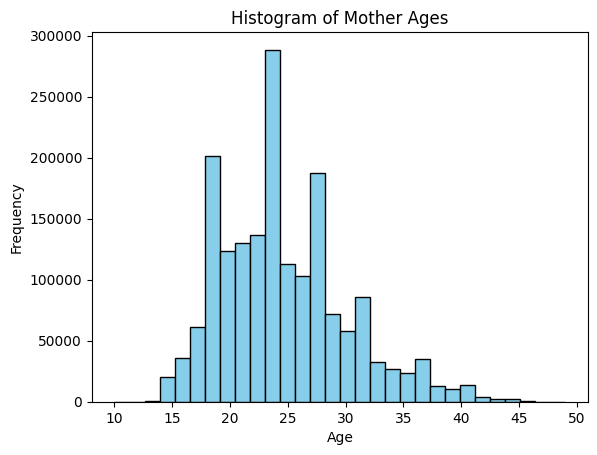

In [7]:
import matplotlib.pyplot as plt

data = births['momage']

plt.hist(data, bins=30, color='skyblue', edgecolor='black')

plt.title('Histogram of Mother Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [8]:
fancy_table = births['birthorder'].value_counts().reset_index(name='count').sort_values(by='birthorder')
fancy_table.style.background_gradient(cmap='Blues')

,birthorder,count
0,1.000000,653359
1,2.000000,476942
2,3.000000,273847
3,4.000000,150094
4,5.000000,83597
5,6.000000,46975
6,7.000000,27686
7,8.000000,16811
8,9.000000,10567
9,10.000000,6539


## Part 2: Download CDC Data
The following code downloads the 1969 U.S. birth data from the National Center for Health Statistics (NCHS) Vital Statistics Online Data Portal, available on the CDC website.

In [9]:
url = 'https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Datasets/DVS/natality/Nat1969.zip'
response = requests.get(url)
filename = os.path.join(save_directory, url.split('/')[-1])

if response.status_code == 200:
    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f"File saved to {filename}")

File saved to data/Nat1969.zip


In [10]:
file_path = Path(filename)

if file_path.is_file():
    print('The file exists.')
else:
    print('File not found.')

The file exists.
